In [1]:
import os, sys, json, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.optim import Adam
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from tqdm import tqdm
import networkx as nx

ROOT    = "/teamspace/studios/this_studio/misinformation-detection"
SRC     = f"{ROOT}/src"
OUTPUTS = f"{ROOT}/outputs"
sys.path.append(SRC) 
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
# graphs
with open(f'{OUTPUTS}/all_cascades.pkl', 'rb') as f:
    cascade_data = pickle.load(f)

# rebuild nx graphs
all_cascades = []
for c in cascade_data:
    G = nx.DiGraph()
    G.add_nodes_from(c['nodes'])
    G.add_edges_from(c['edges'])
    all_cascades.append((G, c['label'], c['root_id'], c['event']))

# embeddings + mapping
all_node_embeddings = np.load(f'{OUTPUTS}/all_node_embeddings.npy')
with open(f'{OUTPUTS}/node_id_to_idx.json') as f:
    node_id_to_idx = json.load(f)

# labels (same order as all_cascades)
labels = np.array([label for _, label, _, _ in all_cascades])

print(f"Cascades         : {len(all_cascades)}")
print(f"Node embeddings  : {all_node_embeddings.shape}")
print(f"Label balance    : {labels.mean():.2%} rumour")

Cascades         : 5802
Node embeddings  : (103572, 768)
Label balance    : 33.99% rumour


In [3]:
import importlib, sys

if 'pyg_data' in sys.modules:
    del sys.modules['pyg_data']

from pyg_data import build_pyg_data

cuts       = [30, 60, 120, None]
cut_labels = ['30min', '60min', '120min', 'full']

datasets = {}
for cut, cut_label in zip(cuts, cut_labels):
    print(f"Building dataset: {cut_label} ...", end=' ')
    data_list = []
    skipped   = 0
    for G, label, root_id, event in all_cascades:
        d = build_pyg_data(G, label, root_id,
                           all_node_embeddings, node_id_to_idx,
                           cut_minutes=cut)
        if d is None:
            skipped += 1
            data_list.append(None)
        else:
            data_list.append(d)
    datasets[cut_label] = data_list
    print(f"{len(data_list) - skipped} valid, {skipped} skipped")

Building dataset: 30min ... 5121 valid, 681 skipped
Building dataset: 60min ... 5259 valid, 543 skipped
Building dataset: 120min ... 5327 valid, 475 skipped
Building dataset: full ... 5447 valid, 355 skipped


In [9]:
from torch_geometric.nn import GCNConv
import torch.nn as nn

class TDrumorGCN(nn.Module):
    def __init__(self, in_feats, hid_feats, out_feats):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hid_feats)
        self.conv2 = GCNConv(hid_feats, out_feats)
        self.bn1   = nn.BatchNorm1d(hid_feats)
        self.bn2   = nn.BatchNorm1d(out_feats)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        return x

class BUrumorGCN(nn.Module):
    def __init__(self, in_feats, hid_feats, out_feats):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hid_feats)
        self.conv2 = GCNConv(hid_feats, out_feats)
        self.bn1   = nn.BatchNorm1d(hid_feats)
        self.bn2   = nn.BatchNorm1d(out_feats)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        return x

class BiGCN(nn.Module):
    def __init__(self, in_feats, hid_feats, out_feats, num_classes=2):
        super().__init__()
        self.td_gcn = TDrumorGCN(in_feats, hid_feats, out_feats)
        self.bu_gcn = BUrumorGCN(in_feats, hid_feats, out_feats)
        self.fc     = nn.Linear(out_feats * 2, num_classes)

    def forward(self, data):
        x             = data.x
        td_edge_index = data.edge_index
        bu_edge_index = data.BU_edge_index
        root_index    = data.root_index

        td_out  = self.td_gcn(x, td_edge_index)
        bu_out  = self.bu_gcn(x, bu_edge_index)

        td_root = td_out[root_index]
        bu_root = bu_out[root_index]

        out = torch.cat([td_root, bu_root], dim=1)
        out = self.fc(out)
        return out

In [10]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out  = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    for data in loader:
        data   = data.to(device)
        out    = model(data)
        probs  = torch.softmax(out, dim=1)[:, 1]
        preds  = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

def run_cv(data_list, labels, n_splits=5,
           hid_feats=128, out_feats=128,
           epochs=50, lr=0.001, batch_size=32):
    """5-fold stratified CV — skips None entries (degenerate cascades)."""

    # filter out None entries but keep track of indices
    valid_idx = [i for i, d in enumerate(data_list) if d is not None]
    valid_data   = [data_list[i] for i in valid_idx]
    valid_labels = labels[valid_idx]

    cv        = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_preds = np.zeros(len(valid_labels), dtype=int)
    all_probs = np.zeros(len(valid_labels))

    for fold, (train_idx, val_idx) in enumerate(
            cv.split(valid_data, valid_labels)):

        print(f"  Fold {fold+1}/{n_splits}", end=' ')

        train_data = [valid_data[i] for i in train_idx]
        val_data   = [valid_data[i] for i in val_idx]

        train_loader = DataLoader(train_data, batch_size=batch_size,
                                  shuffle=True)
        val_loader   = DataLoader(val_data,   batch_size=batch_size,
                                  shuffle=False)

        # class weights
        n_neg    = (valid_labels[train_idx] == 0).sum()
        n_pos    = (valid_labels[train_idx] == 1).sum()
        weights  = torch.tensor([1.0, n_neg/n_pos], dtype=torch.float).to(device)
        criterion = torch.nn.CrossEntropyLoss(weight=weights)

        model     = BiGCN(in_feats=771, hid_feats=hid_feats,
                          out_feats=out_feats).to(device)
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

        for epoch in range(epochs):
            loss = train_epoch(model, train_loader, optimizer, criterion)
            scheduler.step()
            if (epoch + 1) % 10 == 0:
                print(f"    Epoch {epoch+1}/{epochs} | Loss: {loss:.4f}")

        preds, probs, _ = evaluate(model, val_loader)
        all_preds[val_idx] = preds
        all_probs[val_idx] = probs

        fold_f1 = f1_score(valid_labels[val_idx], preds, average='macro')
        print(f"| Macro-F1: {fold_f1:.4f}")

    macro_f1 = f1_score(valid_labels, all_preds, average='macro')
    roc_auc  = roc_auc_score(valid_labels, all_probs)
    print(f"\n  Overall Macro-F1 : {macro_f1:.4f}")
    print(f"  ROC-AUC          : {roc_auc:.4f}")
    print(classification_report(valid_labels, all_preds,
                                 target_names=['non-rumour', 'rumour']))

    return all_preds, all_probs, valid_idx, macro_f1, roc_auc

In [11]:
# sanity check — forward pass on a single batch before committing to full training
from torch_geometric.loader import DataLoader as PyGDataLoader

sample_data = [d for d in datasets['full'][:50] if d is not None]
sample_loader = PyGDataLoader(sample_data, batch_size=8)

model_test = BiGCN(in_feats=771, hid_feats=128, out_feats=128).to(device)

batch = next(iter(sample_loader))
batch = batch.to(device)
out   = model_test(batch)

print(f"Input x shape    : {batch.x.shape}")
print(f"Output shape     : {out.shape}")         # should be (8, 2)
print(f"Sample logits    : {out[:3]}")
print("Forward pass OK")

Input x shape    : torch.Size([97, 771])
Output shape     : torch.Size([8, 2])
Sample logits    : tensor([[-0.5042,  0.8508],
        [ 0.3078,  0.6051],
        [ 0.1495,  0.8451]], device='cuda:0', grad_fn=<SliceBackward0>)
Forward pass OK


In [13]:
bigcn_early_results = {}

for cut_label in cut_labels:
    print(f"\n{'='*50}")
    print(f"Time cut: {cut_label}")
    print(f"{'='*50}")

    preds, probs, valid_idx, macro_f1, roc_auc = run_cv(
        datasets[cut_label],
        labels,
        epochs     = 50,
        hid_feats  = 128,
        out_feats  = 128,
        lr         = 0.001,
        batch_size = 32
    )
    bigcn_early_results[cut_label] = {
        'macro_f1' : macro_f1,
        'roc_auc'  : roc_auc,
        'preds'    : preds,
        'probs'    : probs,
        'valid_idx': valid_idx
    }


Time cut: 30min
  Fold 1/5     Epoch 10/50 | Loss: 0.1284
    Epoch 20/50 | Loss: 0.0650
    Epoch 30/50 | Loss: 0.0197
    Epoch 40/50 | Loss: 0.0182
    Epoch 50/50 | Loss: 0.0105
| Macro-F1: 0.8050
  Fold 2/5     Epoch 10/50 | Loss: 0.1209
    Epoch 20/50 | Loss: 0.0581
    Epoch 30/50 | Loss: 0.0289
    Epoch 40/50 | Loss: 0.0176
    Epoch 50/50 | Loss: 0.0506
| Macro-F1: 0.8158
  Fold 3/5     Epoch 10/50 | Loss: 0.1174
    Epoch 20/50 | Loss: 0.0514
    Epoch 30/50 | Loss: 0.1206
    Epoch 40/50 | Loss: 0.0175
    Epoch 50/50 | Loss: 0.0093
| Macro-F1: 0.8175
  Fold 4/5     Epoch 10/50 | Loss: 0.1069
    Epoch 20/50 | Loss: 0.0581
    Epoch 30/50 | Loss: 0.0168
    Epoch 40/50 | Loss: 0.0201
    Epoch 50/50 | Loss: 0.0254
| Macro-F1: 0.8147
  Fold 5/5     Epoch 10/50 | Loss: 0.1280
    Epoch 20/50 | Loss: 0.0669
    Epoch 30/50 | Loss: 0.0251
    Epoch 40/50 | Loss: 0.0591
    Epoch 50/50 | Loss: 0.0484
| Macro-F1: 0.8124

  Overall Macro-F1 : 0.8131
  ROC-AUC          : 0.9006
 

In [14]:
# save early detection scores for comparison
early_scores = {cut: bigcn_early_results[cut]['macro_f1'] for cut in cut_labels}
pd.DataFrame([early_scores]).to_csv(f'{OUTPUTS}/bigcn_early_detection_scores.csv',
                                     index=False)

# save full-cascade preds for comparison table
np.save(f'{OUTPUTS}/bigcn_preds.npy', bigcn_early_results['full']['preds'])
np.save(f'{OUTPUTS}/bigcn_probs.npy', bigcn_early_results['full']['probs'])
np.save(f'{OUTPUTS}/bigcn_valid_idx.npy',
        bigcn_early_results['full']['valid_idx'])

print("All BiGCN results saved.")

All BiGCN results saved.


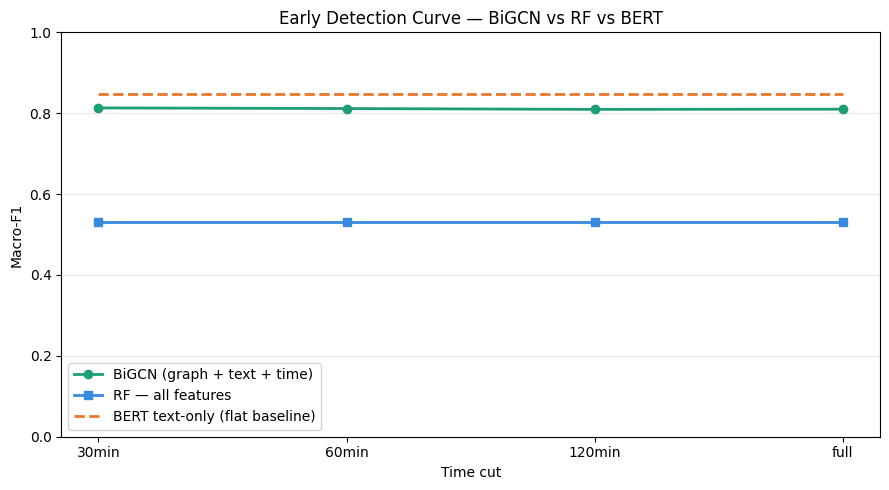


Full-cascade comparison:
Model                            Macro-F1    ROC-AUC
----------------------------------------------------
BERT (text-only)                   0.8470     0.9333
RF (all features)                  0.5304
BiGCN (full cascade)               0.8100     0.9020


In [15]:
import matplotlib.pyplot as plt

# --- early detection curve ---
rf_early = pd.read_csv(f'{OUTPUTS}/rf_early_detection_scores.csv', index_col=0)
bert_f1  = pd.read_csv(f'{OUTPUTS}/bert_results.csv')['macro_f1'].values[0]

bigcn_f1s = [bigcn_early_results[c]['macro_f1'] for c in cut_labels]
rf_f1s    = rf_early['all'].values.tolist()
bert_line = [bert_f1] * len(cut_labels)   # flat — text doesn't change with time

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cut_labels, bigcn_f1s,  marker='o', linewidth=2,
        color='#1D9E75', label='BiGCN (graph + text + time)')
ax.plot(cut_labels, rf_f1s,     marker='s', linewidth=2,
        color='#378ADD', label='RF — all features')
ax.plot(cut_labels, bert_line,  marker='',  linewidth=2,
        linestyle='--', color='#E8772E', label='BERT text-only (flat baseline)')

ax.set_xlabel('Time cut')
ax.set_ylabel('Macro-F1')
ax.set_title('Early Detection Curve — BiGCN vs RF vs BERT')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/early_detection_curve_final.png', dpi=150)
plt.show()

# --- comparison table ---
print("\nFull-cascade comparison:")
print(f"{'Model':<30} {'Macro-F1':>10} {'ROC-AUC':>10}")
print("-" * 52)
print(f"{'BERT (text-only)':<30} {bert_f1:>10.4f} "
      f"{pd.read_csv(f'{OUTPUTS}/bert_results.csv')['roc_auc'].values[0]:>10.4f}")
print(f"{'RF (all features)':<30} "
      f"{rf_early['all']['Full']:>10.4f}")
print(f"{'BiGCN (full cascade)':<30} "
      f"{bigcn_early_results['full']['macro_f1']:>10.4f} "
      f"{bigcn_early_results['full']['roc_auc']:>10.4f}")